[*********************100%***********************]  50 of 50 completed


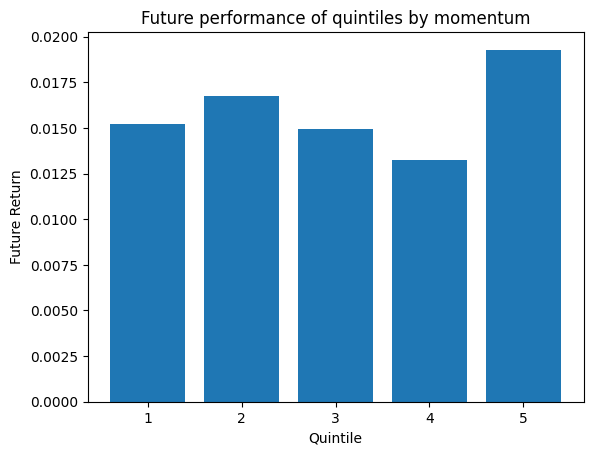

In [23]:
# ── Imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# -- Functions --------------------------------


# ── Universe ─────────────────────────────────────────────────────────
stocks = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "BRK-B", "JPM", "JNJ", "XOM",
    "UNH", "V", "PG", "MA", "HD", "CVX", "MRK", "ABBV", "PEP", "KO",
    "AVGO", "COST", "MCD", "WMT", "BAC", "TMO", "CSCO", "ACN", "NEE", "LIN",
    "ABT", "DHR", "TXN", "CRM", "VZ", "INTC", "QCOM", "AMD", "HON", "UPS",
    "PM", "MS", "GS", "BLK", "SPGI", "AXP", "CAT", "DE", "MMM", "RTX"
]

raw_data = yf.download(stocks, start="2018-01-01", end="2023-12-31")

close_prices = raw_data["Close"]

close_prices_monthly = close_prices.resample("ME").last()

returns_monthly = close_prices_monthly.pct_change()
momentum = (1 + returns_monthly).rolling(window=11).apply(np.prod, raw=True) - 1
momentum = momentum.shift(1)
results = []
valid_dates=momentum.dropna().index
for i, date in enumerate(valid_dates):
    if i == len(valid_dates) - 1: continue
    else:
        month_momentum = momentum.loc[date]
        month_momentum_quintile= pd.qcut(month_momentum, 5,  labels=[1, 2, 3, 4, 5])
        future_returns = returns_monthly.loc[valid_dates[i+1]]
        quintile_future_returns_table = pd.DataFrame({"quintile": month_momentum_quintile, "future_return": future_returns})
        results.append(quintile_future_returns_table)

all_results = pd.concat(results)
grouped_results=all_results.groupby("quintile")["future_return"].mean()

plt.bar(grouped_results.index, grouped_results.values)
plt.title("Future performance of quintiles by momentum")
plt.xlabel("Quintile")
plt.ylabel("Future Return")
plt.show()